In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import sys
sys.path.append('../..')
from common.style import PRIMARY, PRIMARY_DARK, ACCENT, ACCENT_LIGHT, AXIS_COLOR, GRID_COLOR

df = pd.read_excel('../../jhani_pandit_dataset/Fitness_Survey__Responses_clean.xlsx')

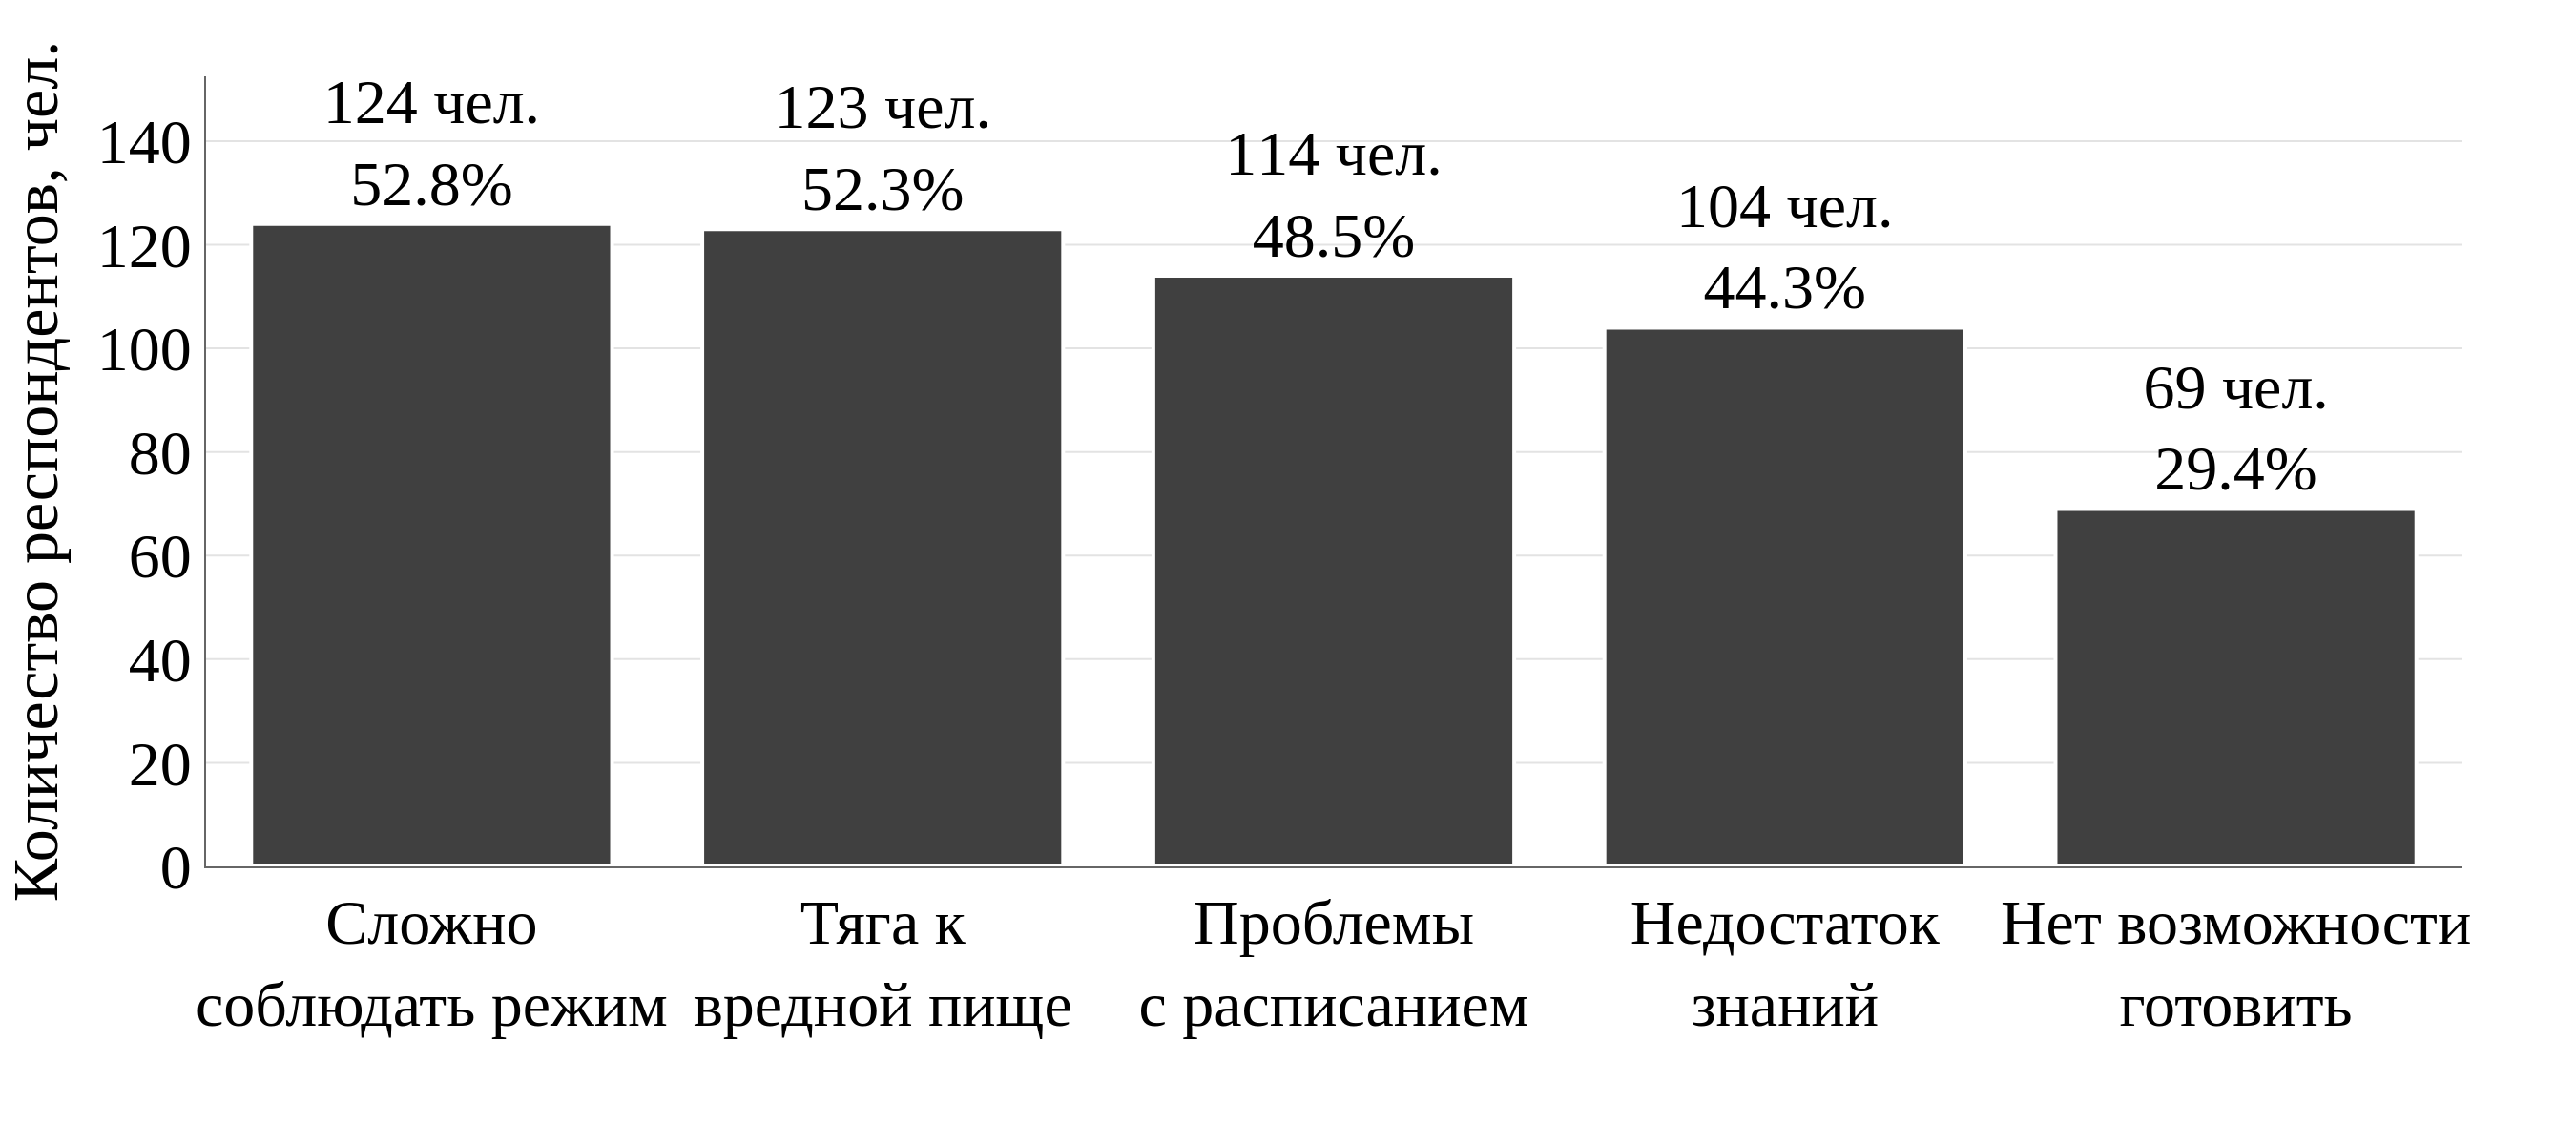

In [2]:
diet_barriers = [
    col for col in df.columns
    if '(diet)' in col
    and col not in ['Barriers_diet', 'Other (diet)', 'No barriers (diet)']
]

diet_data = (
    df[diet_barriers]
    .sum()
    .sort_values(ascending=False)
)

diet_percent = (diet_data / len(df) * 100).round(1)

diet_ru = {
    "Schedule issues (diet)": "Проблемы<br>с расписанием",
    "Junk food temptation (diet)": "Тяга к<br>вредной пище",
    "Too difficult (diet)": "Сложно<br>соблюдать режим",
    "Don't know what/how much to eat (diet)": "Недостаток<br>знаний",
    "Can't cook at home (diet)": "Нет возможности<br>готовить"
}

labels = [diet_ru.get(x, x) for x in diet_data.index]

fig = go.Figure(data=[go.Bar(
    x=labels,
    y=diet_data.values,
    text=[
        f'{count} чел.<br>{pct}%'
        for count, pct in zip(diet_data.values, diet_percent.values)
    ],
    textposition='outside',
    textfont=dict(
        size=33,
        color='#000000',
        family='Times New Roman'
    ),
    marker=dict(
        color=PRIMARY,
        line=dict(color='white', width=2)
    ),
    hovertemplate='<b>%{x}</b><br>Количество: %{y} чел.<extra></extra>'
)])

fig.update_layout(
    showlegend=False,
    paper_bgcolor='white',
    plot_bgcolor='white',
    font=dict(
        family='Times New Roman',
        size=33,
        color='#000000'
    ),
    xaxis=dict(
        title='',
        showgrid=False,
        tickfont=dict(size=33),
        linecolor=AXIS_COLOR,
        linewidth=1,
        tickangle=0
    ),
    yaxis=dict(
        title='Количество респондентов, чел.',
        titlefont=dict(size=34),
        tickfont=dict(size=33),
        showgrid=True,
        gridcolor=GRID_COLOR,
        zeroline=False,
        linecolor=AXIS_COLOR,
        linewidth=1,
        range=[0, diet_data.max() * 1.23]
    ),
    margin=dict(
        l=60,
        r=60,
        t=40,
        b=120
    ),
    width=1350,
    height=600
)

fig.show()